# Calculating Dynamic Modulus $G(t)$

For the purposes of classifying/observing the viscoelastic properties of the bulk polymer, we calculate a time averaged dynamic modulus $\bar G(t)$

$$G(t) = \frac V {k_B T} \langle \sigma_{xy}(t)\sigma_{xy}(0)\rangle$$

$$\bar G(t) = \frac 1 t \int_0^t G(t')dt'$$

(Raffaeli and Ellenbroek)

For smoother curves with more sampling, we average over all possible perpendicular axes,

$$G(t) = \frac V {5 k_BT}\left[\langle\sigma_{xy}(t)\sigma_{xy}(0)\rangle+\langle\sigma_{yz}(t)\sigma_{yz}(0)\rangle+\langle\sigma_{xz}(t)\sigma_{xz}(0)\rangle\right]\\ + \frac V {30 k_BT}\left[\langle N_{xy}(t) N_{xy}(0)\rangle+\langle N_{yz}(t) N_{yz}(0)\rangle+\langle N_{xz}(t) N_{xz}(0)\rangle\right]$$

(Ramirez et al.)

Pressure from LAMMPS is in LJ units.

As noted in the the `compute stress/atom` docs, "per-atom stress is the negative of the per-atom pressure tensor." So, we can simply use the negative $xy$ component of pressure as the $xy$ component of the stress tensor.

However, this then means that 

$$C(t) = \langle (-p_{xy}(t))(-p_{xy}(0))\rangle$$
$$C(t) = \langle p_{xy}(t)p_{xy}(0)\rangle$$

so we can simply replace the stress terms with pressure terms.


## $G(t), \bar G(t)$ function definition

In [1]:
import numpy as np
import multipletau
import scipy

def half_auto_corr(data, fft=False):  
    """Compute the half autocorrelation of a 1D array."""
    if fft:
        # FFT-based autocorrelation
        auto_corr = scipy.signal.correlate(data - np.mean(data), (data - np.mean(data))[::-1], mode='full')
        return auto_corr[auto_corr.size // 2:] / np.arange(len(data), 0, -1)
    
    else:
        # Direct computation
        auto_corr = np.correlate(data - np.mean(data), data - np.mean(data), mode='full')
        half_corr = auto_corr[auto_corr.size // 2:] / np.arange(len(data), 0, -1)
        return half_corr

def N_xy(x, y):
    """Compute the normal stress difference N_xy = P_xx - P_yy."""
    return x - y

def G_func(pxx, pyy, pzz, pxy, pxz, pyz, t, multitau=True, m=16, fft=False):
    """
    Compute the shear relaxation modulus G(t) from stress tensor components.
    Parameters:
    pxx, pyy, pzz, pxy, pxz, pyz : 1D arrays of pressure (-ve stress) tensor components over time
    t : 1D array of time points
    Returns:
    G_t : 1D array of shear relaxation modulus G(t)
    t : 1D array of time points
    """
    kB = 1.0       # Boltzmann constant = 1 in LJ units
    T = 1.0        # temperature
    V = 40**3      # volume

    if multitau:
        print("Using multitau correlation...")
        print("deltat:", (t[1]-t[0]) * 0.001)
        print("Computing autocorrelation of N_xy...")
        auto_corr_Nxy = multipletau.autocorrelate(N_xy(pxx, pyy) - np.mean(N_xy(pxx, pyy)), deltat=(t[1]-t[0] * 0.001), m=m)[:, 1]
        print("Computing autocorrelation of N_xz...")
        auto_corr_Nxz = multipletau.autocorrelate(N_xy(pxx, pzz) - np.mean(N_xy(pxx, pzz)), deltat=(t[1]-t[0] * 0.001), m=m)[:, 1]
        print("Computing autocorrelation of N_yz...")
        auto_corr_Nyz = multipletau.autocorrelate(N_xy(pyy, pzz) - np.mean(N_xy(pyy, pzz)), deltat=(t[1]-t[0] * 0.001), m=m)[:, 1]
        print("Computing autocorrelation of pxy...")
        auto_corr_xy = multipletau.autocorrelate(pxy - np.mean(pxy), deltat=(t[1]-t[0] * 0.001), m=m)[:, 1]
        print("Computing autocorrelation of pxz...")
        auto_corr_xz = multipletau.autocorrelate(pxz - np.mean(pxz), deltat=(t[1]-t[0] * 0.001), m=m)[:, 1]
        print("Computing autocorrelation of pyz...")
        auto_corr_yz = multipletau.autocorrelate(pyz - np.mean(pyz), deltat=(t[1]-t[0] * 0.001), m=m)

        t = auto_corr_yz[:, 0]
        auto_corr_yz = auto_corr_yz[:, 1]
    else:
        # average over all perpendicular axes
        print("Using standard correlation...")
        print("Computing half autocorrelation of N_xy...")
        auto_corr_Nxy = half_auto_corr(N_xy(pxx, pyy), fft=fft)
        print("Computing half autocorrelation of N_xz...")
        auto_corr_Nxz = half_auto_corr(N_xy(pxx, pzz), fft=fft)
        print("Computing half autocorrelation of N_yz...")
        auto_corr_Nyz = half_auto_corr(N_xy(pyy, pzz), fft=fft)
        print("Computing half autocorrelation of pxy...")
        auto_corr_xy = half_auto_corr(pxy, fft=fft)
        print("Computing half autocorrelation of pxz...")
        auto_corr_xz = half_auto_corr(pxz, fft=fft)
        print("Computing half autocorrelation of pyz...")
        auto_corr_yz = half_auto_corr(pyz, fft=fft)

    G_t = (auto_corr_xy + auto_corr_yz + auto_corr_xz) / 5.0 + \
            (auto_corr_Nxy + auto_corr_Nxz + auto_corr_Nyz) / 30.0

    G_t *= V / (kB * T)

    return G_t, t

def overline_G_func(pxx, pyy, pzz, pxy, pxz, pyz, t):
    G_t = G_func(pxx, pyy, pzz, pxy, pxz, pyz, t)[0]
    time = t
    dt = time[1] - time[0]

    overline_G = np.cumsum(G_t) * dt / time
    overline_G[0] = overline_G[1]  # avoid division by zero
    overline_G /= overline_G[0]  # normalize by G(0)
    
    return overline_G, time


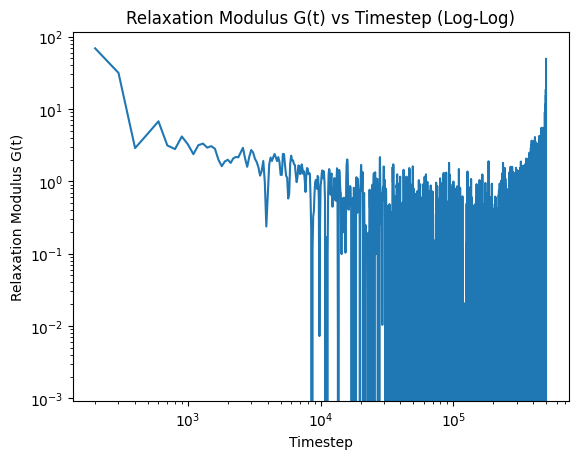

In [4]:
import multipletau
import pandas as pd
import matplotlib.pyplot as plt

file = "logs/press_0_0.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
# print(data.head())

pxx = data['pxy'].values
G_t, time = G_func(data['pxx'], data['pyy'], data['pzz'], data['pxy'], data['pxz'], data['pyz'], data['timestep'], multitau=False)

# overline_G = np.cumsum(G_t) * (time[1] - time[0]) / time
# overline_G[0] = overline_G[1]  # avoid division by zero
# overline_G /= overline_G[0]  # normalize by G(0)

plt.loglog(time, G_t)
# plt.loglog(time, overline_G)
plt.xlabel('Timestep')
plt.ylabel('Relaxation Modulus G(t)')
plt.title('Relaxation Modulus G(t) vs Timestep (Log-Log)')
plt.show()


## Long time + larger box


2400000
Using standard correlation...
Computing half autocorrelation of N_xy...
Computing half autocorrelation of N_xz...
Computing half autocorrelation of N_yz...
Computing half autocorrelation of pxy...
Computing half autocorrelation of pxz...
Computing half autocorrelation of pyz...


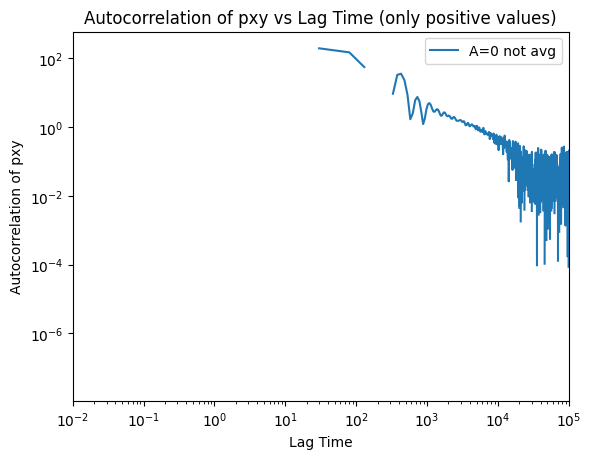

In [2]:
import multipletau
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

file = f"logs/press_test_freq.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])

pxx = data['pxx'].values
pyy = data['pyy'].values
pzz = data['pzz'].values
pxy = data['pxy'].values
pxz = data['pxz'].values
pyz = data['pyz'].values
time = data['timestep'].values

# average pressure over every 10 steps
binsize = 5
pxx = np.mean(pxx.reshape(-1, binsize), axis=1)
pyy = np.mean(pyy.reshape(-1, binsize), axis=1)
pzz = np.mean(pzz.reshape(-1, binsize), axis=1)
pxy = np.mean(pxy.reshape(-1, binsize), axis=1)
pxz = np.mean(pxz.reshape(-1, binsize), axis=1)
pyz = np.mean(pyz.reshape(-1, binsize), axis=1)
time = np.mean(time.reshape(-1, binsize), axis=1)



# corr = multipletau.autocorrelate(pxx - np.mean(pxx), m=60, deltat=0.001 * 10)   # timestep 0.001, output every 100 steps

# t = corr[:, 0]
# G = corr[:, 1]
print(len(pxx))
corr = G_func(pxx, pyy, pzz, pxy, pxz, pyz, time, multitau=False, fft=False)
t = corr[1]
G = corr[0]


G  = np.ma.masked_where(G <= 0, G)
t  = np.ma.masked_where(G <= 0, t)

# print(corr)
plt.loglog(t, G, label=f'A={0} not avg')
# plt.loglog(corr[:,0], -corr[:,1])
# plt.plot(corr)
plt.xlabel('Lag Time')
plt.ylabel('Autocorrelation of pxy')
# plt.ylim(1e-6, 1e3)
plt.xlim(1e-2, 1e5)
plt.legend()
plt.title('Autocorrelation of pxy vs Lag Time (only positive values)')
plt.show()

Looking for any periodic artifacts in p_xy

12000000


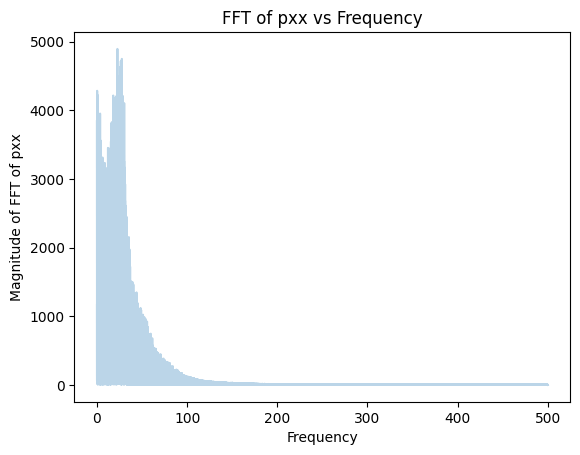

In [1]:
import multipletau
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

file = f"logs/press_test_freq.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
pxx = data['pxx'].values
print(len(pxx))

# pxx = np.pad(pxx, (0, 2**20 - len(pxx)), 'constant', constant_values=(0, 0))
fourier_transform = np.fft.fft(pxx - np.mean(pxx))
frequencies = np.fft.fftfreq(len(pxx), d=0.001)
magnitude = np.abs(fourier_transform)

plt.plot(frequencies[1:len(frequencies)//2], magnitude[1:len(magnitude)//2], label='test (damping param = 100)', alpha=0.3)
plt.xlabel('Frequency')
plt.ylabel('Magnitude of FFT of pxx')
plt.title('FFT of pxx vs Frequency')


# file = f"logs/press_0_0_long.dat"
# data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
# pxx = data['pxx'].values
# print(len(pxx))

# pxx = np.pad(pxx, (0, 2**20 - len(pxx)), 'constant', constant_values=(0, 0))


# fourier_transform = np.fft.fft(pxx - np.mean(pxx))
# frequencies = np.fft.fftfreq(len(pxx), d=0.001)
# magnitude = np.abs(fourier_transform)

# plt.plot(frequencies[1:len(frequencies)//2], magnitude[1:len(magnitude)//2], label='test (damping param = 200)', alpha=0.3)
# plt.xlabel('Frequency')
# plt.ylabel('Magnitude of FFT of pxx')
# plt.title('FFT of pxx vs Frequency')
# plt.ylim(0, 4e3)
# plt.legend()
plt.show()

    time      px_y      px_z      py_z       pxy       pxz       pyz
0  0.001  0.003337  0.003338  0.003333  0.000834  0.000832  0.000835
1  0.002  0.003336  0.003337  0.003332  0.000834  0.000832  0.000835
2  0.003  0.003335  0.003335  0.003330  0.000833  0.000832  0.000835
3  0.004  0.003332  0.003333  0.003328  0.000833  0.000831  0.000834
4  0.005  0.003329  0.003330  0.003325  0.000832  0.000830  0.000834
nan nan


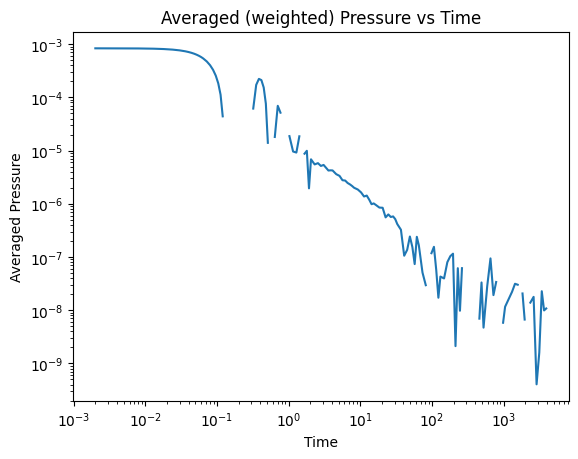

In [2]:
file = f"long_corr.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])

start = 1

data = data[start:].reset_index(drop=True)

ave_press = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
            (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

# replace negative with NaN
ave_press = np.where(ave_press < 0, np.nan, ave_press)


# ave_press *= 40**3 / (1.0 * 1.0)  # V / (kB * T)

print(data.head())
print(ave_press.min(), ave_press.max())
plt.loglog(data['time'][start:], ave_press[start:])
plt.xlabel('Time')
plt.ylabel('Averaged Pressure')
plt.title('Averaged (weighted) Pressure vs Time')
plt.show()